In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Verify the trained checkpoint exists
!ls -lh /content/drive/MyDrive/edgeminer/checkpoints/best.pt

Mounted at /content/drive
-rw------- 1 root root 93M May 16 12:39 /content/drive/MyDrive/edgeminer/checkpoints/best.pt


In [3]:
!mkdir -p /content/data/nuscenes
!tar -xzf /content/drive/MyDrive/v1.0-mini.tgz -C /content/data/nuscenes

In [4]:
!pip install nuscenes-devkit faiss-cpu -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.0/316.0 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 107.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 13.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pointpats 2.5.5 requires shapely>=2.1, but you have shapely 2.0.7 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
esda 2.9.0 requi

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!ls /content/data/nuscenes  # data should still be there from before restart

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LICENSE  maps  samples	sweeps	v1.0-mini


In [2]:
import torch
print(f"CUDA: {torch.cuda.is_available()}, Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

CUDA: True, Device: Tesla T4


In [3]:
from pathlib import Path
from typing import Optional

import numpy as np
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import LidarPointCloud


class NuScenesPairs(Dataset):
    """
    Camera-LiDAR paired dataset for contrastive learning.

    For each nuScenes sample, returns:
        - front camera image, resized + normalized
        - LiDAR point cloud, downsampled to a fixed number of points
        - sample token (string) for traceability into retrieval / evaluation
    """

    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD = [0.229, 0.224, 0.225]

    def __init__(
        self,
        dataroot: str,
        version: str = "v1.0-mini",
        camera_channel: str = "CAM_FRONT",
        image_size: int = 224,
        num_lidar_points: int = 4096,
        split_tokens: Optional[list] = None,
    ):
        """
        Args:
            dataroot: path to nuScenes data folder (contains v1.0-mini/, samples/, etc.)
            version: dataset version, "v1.0-mini" or "v1.0-trainval"
            camera_channel: which camera to use, default front
            image_size: square crop size for image encoder
            num_lidar_points: number of points to sample from each LiDAR sweep
            split_tokens: optional list of sample tokens to restrict to (for train/val split)
        """
        self.dataroot = Path(dataroot)
        self.nusc = NuScenes(version=version, dataroot=str(dataroot), verbose=False)
        self.camera_channel = camera_channel
        self.num_lidar_points = num_lidar_points

        if split_tokens is not None:
            self.samples = [s for s in self.nusc.sample if s["token"] in split_tokens]
        else:
            self.samples = list(self.nusc.sample)

        self.image_transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=self.IMAGENET_MEAN, std=self.IMAGENET_STD),
        ])

    def __len__(self) -> int:
        return len(self.samples)

    def _load_image(self, sample: dict) -> torch.Tensor:
        cam_data = self.nusc.get("sample_data", sample["data"][self.camera_channel])
        img_path = self.dataroot / cam_data["filename"]
        img = Image.open(img_path).convert("RGB")
        return self.image_transform(img)

    def _load_lidar(self, sample: dict) -> torch.Tensor:
        lidar_data = self.nusc.get("sample_data", sample["data"]["LIDAR_TOP"])
        lidar_path = self.dataroot / lidar_data["filename"]
        pc = LidarPointCloud.from_file(str(lidar_path))
        # pc.points has shape (4, N): x, y, z, intensity
        points = pc.points.T  # (N, 4)

        # Random sampling to fixed size for batching.
        # Production systems use farthest point sampling — random is fine for a baseline.
        n = points.shape[0]
        if n >= self.num_lidar_points:
            idx = np.random.choice(n, self.num_lidar_points, replace=False)
        else:
            idx = np.random.choice(n, self.num_lidar_points, replace=True)
        points = points[idx]

        return torch.from_numpy(points).float()

    def __getitem__(self, idx: int) -> dict:
        sample = self.samples[idx]
        return {
            "image": self._load_image(sample),
            "lidar": self._load_lidar(sample),
            "token": sample["token"],
        }


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ImageEncoder(nn.Module):
    """DINOv2 ViT-S/14 backbone with a small projection head."""

    def __init__(self, embed_dim: int = 256, freeze_backbone: bool = True):
        super().__init__()
        # DINOv2 small, pretrained, self-supervised — great fit for the JD narrative
        self.backbone = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14")
        backbone_dim = 384  # ViT-S output dim

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        self.projection = nn.Sequential(
            nn.Linear(backbone_dim, 512),
            nn.GELU(),
            nn.Linear(512, embed_dim),
        )

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        # DINOv2 expects 14-pixel multiples — resize input from 224 to 224 (16*14) is fine
        features = self.backbone(images)  # (B, 384)
        emb = self.projection(features)   # (B, embed_dim)
        return F.normalize(emb, dim=-1)


class PointNetEncoder(nn.Module):
    """
    Minimal PointNet for LiDAR. Permutation-invariant via max pooling.

    Input: (B, N, 4) — N points with (x, y, z, intensity)
    Output: (B, embed_dim), L2 normalized
    """

    def __init__(self, embed_dim: int = 256, input_channels: int = 4):
        super().__init__()
        self.point_mlp = nn.Sequential(
            nn.Conv1d(input_channels, 64, 1),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Conv1d(64, 128, 1),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Conv1d(128, 256, 1),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Conv1d(256, 512, 1),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
        )
        self.projection = nn.Sequential(
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Linear(256, embed_dim),
        )

    def forward(self, points: torch.Tensor) -> torch.Tensor:
        # points: (B, N, 4) -> (B, 4, N) for Conv1d
        x = points.transpose(1, 2)
        x = self.point_mlp(x)            # (B, 512, N)
        x = torch.max(x, dim=2).values   # (B, 512), permutation-invariant
        emb = self.projection(x)         # (B, embed_dim)
        return F.normalize(emb, dim=-1)


class DualEncoder(nn.Module):
    """
    Wraps the camera and LiDAR towers into a single module.

    forward() returns a dict with both embeddings for use in InfoNCE loss.
    """

    def __init__(self, embed_dim: int = 256, freeze_image_backbone: bool = True):
        super().__init__()
        self.image_encoder = ImageEncoder(embed_dim=embed_dim, freeze_backbone=freeze_image_backbone)
        self.lidar_encoder = PointNetEncoder(embed_dim=embed_dim)
        # Learnable temperature, CLIP-style. Starts at 0.07 (in log space: ln(1/0.07) ≈ 2.66).
        self.logit_scale = nn.Parameter(torch.tensor(2.66))

    def forward(self, images: torch.Tensor, points: torch.Tensor) -> dict:
        return {
            "image_emb": self.image_encoder(images),
            "lidar_emb": self.lidar_encoder(points),
            "logit_scale": self.logit_scale.exp().clamp(max=100.0),
        }


def info_nce_loss(image_emb: torch.Tensor, lidar_emb: torch.Tensor, logit_scale: torch.Tensor) -> torch.Tensor:
    """
    Symmetric InfoNCE loss (CLIP-style).

    Diagonal of the similarity matrix is positive pairs (same sample),
    off-diagonal is negatives (different samples in the batch).
    """
    logits = logit_scale * image_emb @ lidar_emb.t()        # (B, B)
    labels = torch.arange(logits.size(0), device=logits.device)
    loss_i2l = F.cross_entropy(logits, labels)
    loss_l2i = F.cross_entropy(logits.t(), labels)
    return (loss_i2l + loss_l2i) / 2


In [6]:
"""
Extract embeddings from a trained EdgeMiner checkpoint over the full dataset.

Output: a single .pt file containing:
    - image_embeddings: (N, D) tensor
    - lidar_embeddings: (N, D) tensor
    - sample_tokens: list of N strings
    - metadata: dict (checkpoint path, model config, dataset version)

Usage in Colab (with NuScenesPairs and DualEncoder already in namespace):
    from src.retrieval.embedding_extractor import extract_embeddings
    extract_embeddings(
        checkpoint_path='/content/drive/MyDrive/edgeminer/checkpoints/best.pt',
        dataroot='/content/data/nuscenes',
        output_path='/content/drive/MyDrive/edgeminer/embeddings/all.pt',
    )
"""

from pathlib import Path
from typing import Optional

import torch
from torch.utils.data import DataLoader
from tqdm import tqdm

try:
    from src.data.nuscenes_loader import NuScenesPairs
    from src.models.dual_encoder import DualEncoder
except ImportError:
    pass  # Assume classes are in Colab namespace


@torch.no_grad()
def extract_embeddings(
    checkpoint_path: str,
    dataroot: str,
    output_path: str,
    version: str = "v1.0-mini",
    batch_size: int = 32,
    num_workers: int = 2,
    embed_dim: int = 256,
    device: Optional[str] = None,
) -> dict:
    """
    Run the trained dual encoder over every sample and save embeddings.

    Returns the same dict that gets saved to disk.
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Extracting embeddings on: {device}")

    # ---- Load checkpoint ----
    print(f"Loading checkpoint from: {checkpoint_path}")
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)

    model = DualEncoder(embed_dim=embed_dim, freeze_image_backbone=True).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    print(f"  Checkpoint trained for {ckpt.get('epoch', '?')} epochs")
    if "metrics" in ckpt:
        m = ckpt["metrics"]
        print(f"  Val metrics at this checkpoint: "
              f"R@1={m.get('recall@1', 0):.3f}, "
              f"R@5={m.get('recall@5', 0):.3f}, "
              f"R@10={m.get('recall@10', 0):.3f}")

    # ---- Load full dataset (no train/val split — we embed everything) ----
    dataset = NuScenesPairs(dataroot=dataroot, version=version)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,  # CRITICAL: preserve order so tokens line up with embeddings
        num_workers=num_workers,
        pin_memory=True,
    )
    print(f"Extracting embeddings for {len(dataset)} samples...")

    # ---- Forward pass over everything ----
    all_image_emb, all_lidar_emb, all_tokens = [], [], []

    for batch in tqdm(loader, desc="Encoding"):
        images = batch["image"].to(device, non_blocking=True)
        points = batch["lidar"].to(device, non_blocking=True)
        out = model(images, points)
        all_image_emb.append(out["image_emb"].cpu())
        all_lidar_emb.append(out["lidar_emb"].cpu())
        all_tokens.extend(batch["token"])

    image_emb = torch.cat(all_image_emb, dim=0)
    lidar_emb = torch.cat(all_lidar_emb, dim=0)

    print(f"\nDone. Image embeddings: {image_emb.shape}, LiDAR: {lidar_emb.shape}")
    print(f"All embeddings L2-normalized: "
          f"img_norm={image_emb.norm(dim=-1).mean().item():.4f}, "
          f"lidar_norm={lidar_emb.norm(dim=-1).mean().item():.4f}")

    # ---- Save ----
    output = {
        "image_embeddings": image_emb,
        "lidar_embeddings": lidar_emb,
        "sample_tokens": all_tokens,
        "metadata": {
            "checkpoint_path": str(checkpoint_path),
            "checkpoint_epoch": ckpt.get("epoch"),
            "checkpoint_metrics": ckpt.get("metrics"),
            "dataset_version": version,
            "embed_dim": embed_dim,
            "num_samples": len(all_tokens),
        },
    }
    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    torch.save(output, output_path)
    print(f"Saved to: {output_path}")

    return output

In [7]:
"""
FAISS index wrapper for EdgeMiner retrieval.

Supports:
    - Building image and LiDAR indices from saved embeddings
    - Cross-modal queries (image -> LiDAR, LiDAR -> image)
    - Within-modal queries (image -> image, "find scenes that look like this")
    - Persistence to disk

For 404 samples we use a simple exact index (IndexFlatIP for cosine similarity
on L2-normalized vectors). For larger datasets you'd swap to IndexIVFPQ or HNSW.

Usage:
    from src.retrieval.faiss_index import EdgeMinerIndex

    index = EdgeMinerIndex.from_embeddings_file(
        '/content/drive/MyDrive/edgeminer/embeddings/all.pt'
    )
    # Query: given image #5, find the 5 most similar LiDAR scenes
    results = index.query_image_to_lidar(query_idx=5, k=5)
"""

from pathlib import Path
from typing import Optional, Union

import numpy as np
import torch

try:
    import faiss
except ImportError:
    raise ImportError(
        "FAISS not installed. In Colab: !pip install faiss-cpu -q"
    )


class EdgeMinerIndex:
    """
    Holds FAISS indices for image and LiDAR embeddings, supports cross-modal search.

    Because embeddings are L2-normalized, inner product equals cosine similarity.
    We use IndexFlatIP for exact search (fine for thousands of samples).
    """

    def __init__(
        self,
        image_embeddings: np.ndarray,
        lidar_embeddings: np.ndarray,
        sample_tokens: list,
        metadata: Optional[dict] = None,
    ):
        assert image_embeddings.shape == lidar_embeddings.shape, \
            f"Shape mismatch: {image_embeddings.shape} vs {lidar_embeddings.shape}"
        assert len(sample_tokens) == image_embeddings.shape[0], \
            f"Token count {len(sample_tokens)} != embedding count {image_embeddings.shape[0]}"

        self.image_embeddings = image_embeddings.astype(np.float32)
        self.lidar_embeddings = lidar_embeddings.astype(np.float32)
        self.sample_tokens = sample_tokens
        self.metadata = metadata or {}

        d = image_embeddings.shape[1]
        # IndexFlatIP = inner product. L2-normalized -> cosine similarity.
        self.image_index = faiss.IndexFlatIP(d)
        self.lidar_index = faiss.IndexFlatIP(d)
        self.image_index.add(self.image_embeddings)
        self.lidar_index.add(self.lidar_embeddings)

        print(f"EdgeMinerIndex built: {len(sample_tokens)} samples, dim={d}")

    @classmethod
    def from_embeddings_file(cls, path: str) -> "EdgeMinerIndex":
        """Load from the .pt file produced by extract_embeddings()."""
        data = torch.load(path, map_location="cpu", weights_only=False)
        return cls(
            image_embeddings=data["image_embeddings"].numpy(),
            lidar_embeddings=data["lidar_embeddings"].numpy(),
            sample_tokens=data["sample_tokens"],
            metadata=data.get("metadata"),
        )

    # -------- Querying --------

    def _query(
        self,
        query_vec: np.ndarray,
        target_index: "faiss.Index",
        k: int,
    ) -> list:
        """Run a k-NN search and return list of dicts with token + similarity score."""
        if query_vec.ndim == 1:
            query_vec = query_vec.reshape(1, -1)
        query_vec = query_vec.astype(np.float32)

        similarities, indices = target_index.search(query_vec, k)
        results = []
        for sim, idx in zip(similarities[0], indices[0]):
            results.append({
                "sample_token": self.sample_tokens[idx],
                "similarity": float(sim),
                "index": int(idx),
            })
        return results

    def query_image_to_lidar(self, query_idx: int, k: int = 5) -> list:
        """Given an image (by index), retrieve top-K matching LiDAR scans."""
        return self._query(self.image_embeddings[query_idx], self.lidar_index, k)

    def query_lidar_to_image(self, query_idx: int, k: int = 5) -> list:
        """Given a LiDAR scan (by index), retrieve top-K matching images."""
        return self._query(self.lidar_embeddings[query_idx], self.image_index, k)

    def query_image_to_image(self, query_idx: int, k: int = 5) -> list:
        """Find visually similar scenes in the image modality."""
        return self._query(self.image_embeddings[query_idx], self.image_index, k)

    def query_lidar_to_lidar(self, query_idx: int, k: int = 5) -> list:
        """Find scenes with similar 3D structure."""
        return self._query(self.lidar_embeddings[query_idx], self.lidar_index, k)

    def query_with_vector(
        self,
        query_vec: Union[np.ndarray, torch.Tensor],
        target_modality: str = "image",
        k: int = 5,
    ) -> list:
        """
        Query with an arbitrary embedding vector (e.g., from a new image).

        Args:
            query_vec: (D,) or (1, D) embedding
            target_modality: "image" or "lidar" — which index to search
            k: number of results
        """
        if isinstance(query_vec, torch.Tensor):
            query_vec = query_vec.detach().cpu().numpy()
        target = self.image_index if target_modality == "image" else self.lidar_index
        return self._query(query_vec, target, k)

    # -------- Persistence --------

    def save(self, dir_path: str):
        """Save FAISS indices + embeddings to disk."""
        d = Path(dir_path)
        d.mkdir(parents=True, exist_ok=True)
        faiss.write_index(self.image_index, str(d / "image.faiss"))
        faiss.write_index(self.lidar_index, str(d / "lidar.faiss"))
        torch.save({
            "image_embeddings": torch.from_numpy(self.image_embeddings),
            "lidar_embeddings": torch.from_numpy(self.lidar_embeddings),
            "sample_tokens": self.sample_tokens,
            "metadata": self.metadata,
        }, d / "embeddings.pt")
        print(f"Saved index to: {dir_path}")

    @classmethod
    def load(cls, dir_path: str) -> "EdgeMinerIndex":
        d = Path(dir_path)
        return cls.from_embeddings_file(str(d / "embeddings.pt"))

In [8]:
embeddings_data = extract_embeddings(
    checkpoint_path='/content/drive/MyDrive/edgeminer/checkpoints/best.pt',
    dataroot='/content/data/nuscenes',
    output_path='/content/drive/MyDrive/edgeminer/embeddings/all.pt',
    batch_size=32,
)

Extracting embeddings on: cuda
Loading checkpoint from: /content/drive/MyDrive/edgeminer/checkpoints/best.pt
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 411MB/s]


  Checkpoint trained for 16 epochs
  Val metrics at this checkpoint: R@1=0.538, R@5=0.975, R@10=1.000
Extracting embeddings for 404 samples...


Encoding: 100%|██████████| 13/13 [00:09<00:00,  1.35it/s]


Done. Image embeddings: torch.Size([404, 256]), LiDAR: torch.Size([404, 256])
All embeddings L2-normalized: img_norm=1.0000, lidar_norm=1.0000
Saved to: /content/drive/MyDrive/edgeminer/embeddings/all.pt


In [9]:
index = EdgeMinerIndex.from_embeddings_file(
    '/content/drive/MyDrive/edgeminer/embeddings/all.pt'
)

EdgeMinerIndex built: 404 samples, dim=256


In [10]:
# Query: image #0 should retrieve LiDAR #0 as its top match (or very close)
# This is the "Recall@1" test, live
results = index.query_image_to_lidar(query_idx=0, k=5)
print("Query: image at index 0 → top-5 LiDAR matches")
for r in results:
    print(f"  idx={r['index']:3d}  sim={r['similarity']:.4f}  token={r['sample_token'][:8]}...")

Query: image at index 0 → top-5 LiDAR matches
  idx=  1  sim=0.6186  token=39586f9d...
  idx=  0  sim=0.6138  token=ca9a282c...
  idx=  3  sim=0.5663  token=e0845f53...
  idx=  2  sim=0.5613  token=356d81f3...
  idx=317  sim=0.4722  token=05e993bd...


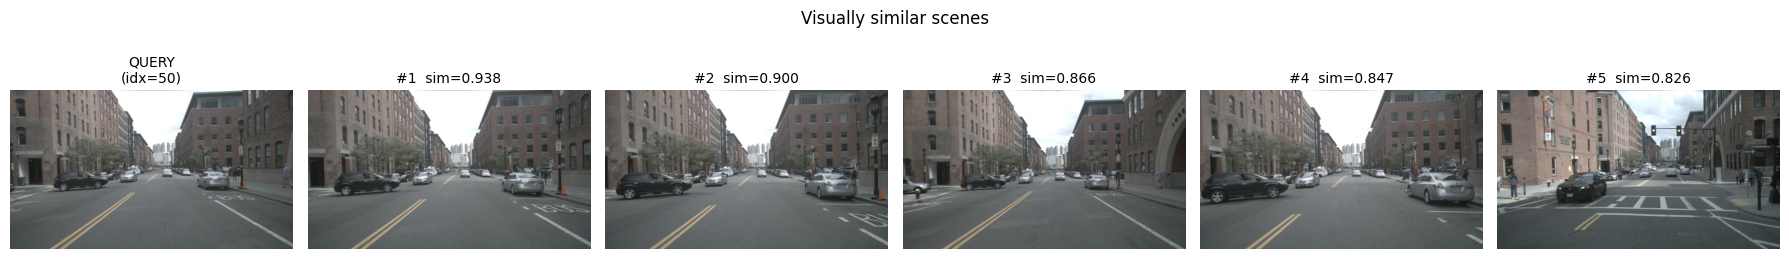

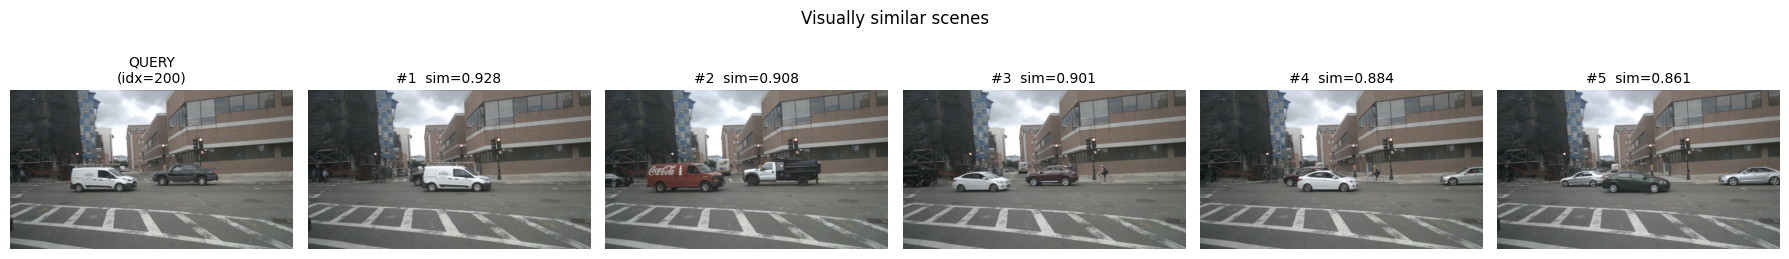

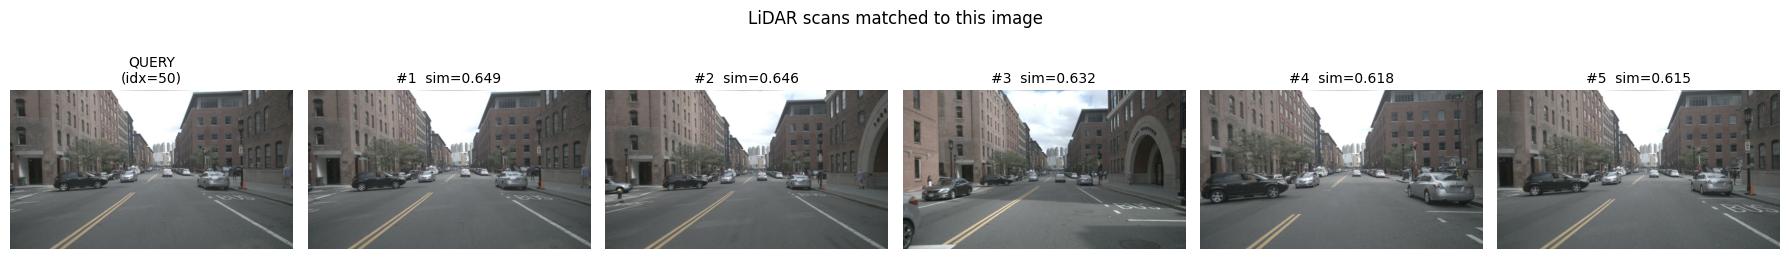

In [11]:
import matplotlib.pyplot as plt
from PIL import Image
from nuscenes.nuscenes import NuScenes

nusc = NuScenes(version='v1.0-mini', dataroot='/content/data/nuscenes', verbose=False)

def show_retrieval(query_idx, k=5, mode='image_to_image'):
    """Visualize top-K retrievals for a query."""

    # Get query token + retrieved tokens
    query_token = index.sample_tokens[query_idx]

    if mode == 'image_to_image':
        results = index.query_image_to_image(query_idx, k=k+1)  # +1 because top-1 is self
        results = results[1:]  # drop self-match
        title_suffix = "Visually similar scenes"
    elif mode == 'image_to_lidar':
        results = index.query_image_to_lidar(query_idx, k=k)
        title_suffix = "LiDAR scans matched to this image"

    # Render
    fig, axes = plt.subplots(1, k+1, figsize=(3*(k+1), 3))

    def render_camera(token, ax, label):
        sample = nusc.get('sample', token)
        cam_data = nusc.get('sample_data', sample['data']['CAM_FRONT'])
        img_path = f"/content/data/nuscenes/{cam_data['filename']}"
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(label, fontsize=10)
        ax.axis('off')

    render_camera(query_token, axes[0], f"QUERY\n(idx={query_idx})")
    for i, r in enumerate(results):
        render_camera(r['sample_token'], axes[i+1], f"#{i+1}  sim={r['similarity']:.3f}")

    plt.suptitle(title_suffix, fontsize=12)
    plt.tight_layout()
    plt.show()

# Demo: visually-similar-scene search
show_retrieval(query_idx=50, k=5, mode='image_to_image')
show_retrieval(query_idx=200, k=5, mode='image_to_image')

# Demo: cross-modal (image -> LiDAR)
show_retrieval(query_idx=50, k=5, mode='image_to_lidar')

In [12]:
index.save('/content/drive/MyDrive/edgeminer/index')

Saved index to: /content/drive/MyDrive/edgeminer/index


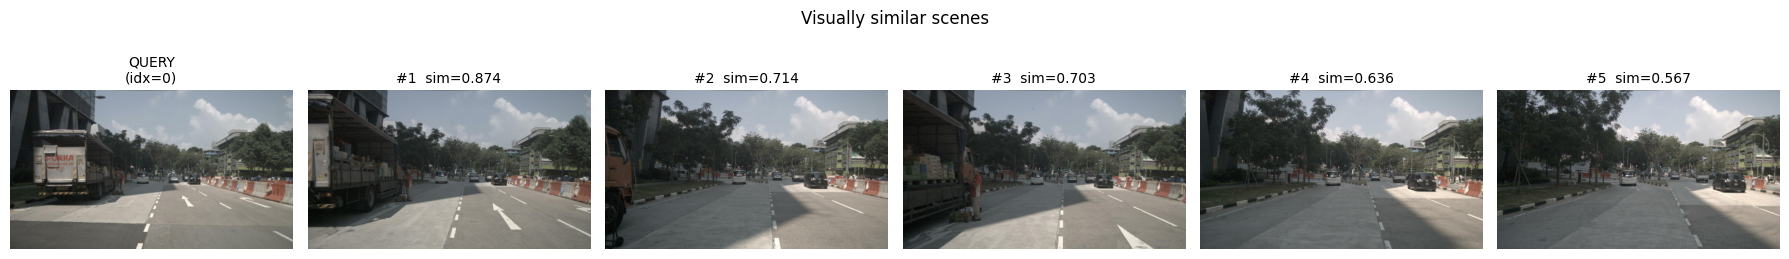

In [13]:
show_retrieval(query_idx=0, k=5, mode='image_to_image')

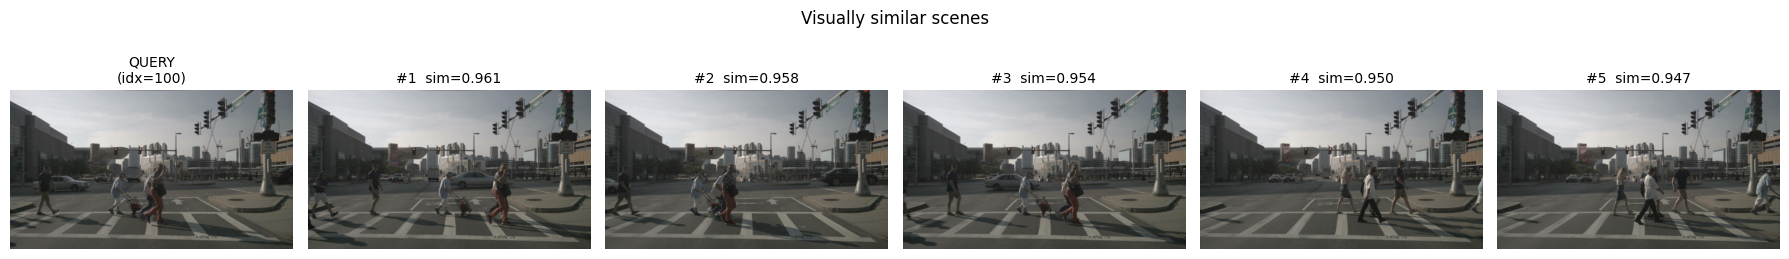

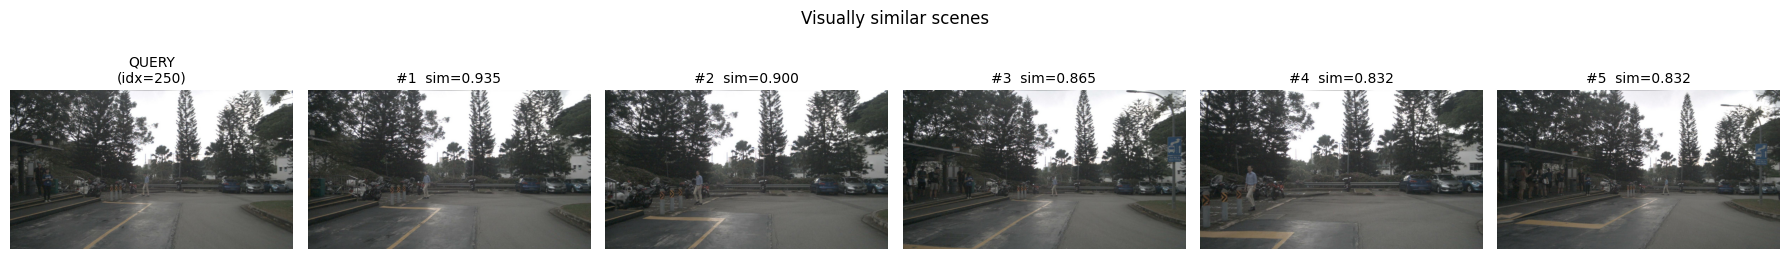

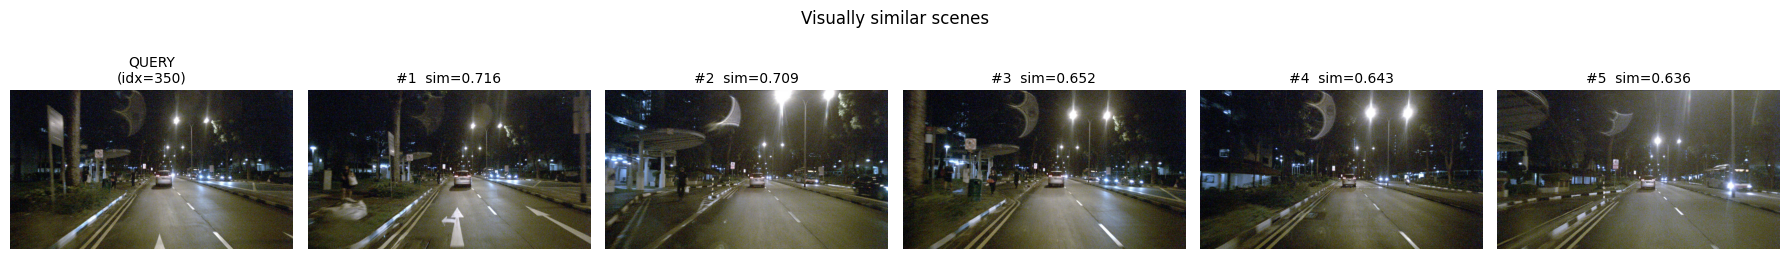

In [14]:
show_retrieval(query_idx=100, k=5, mode='image_to_image')
show_retrieval(query_idx=250, k=5, mode='image_to_image')
show_retrieval(query_idx=350, k=5, mode='image_to_image')

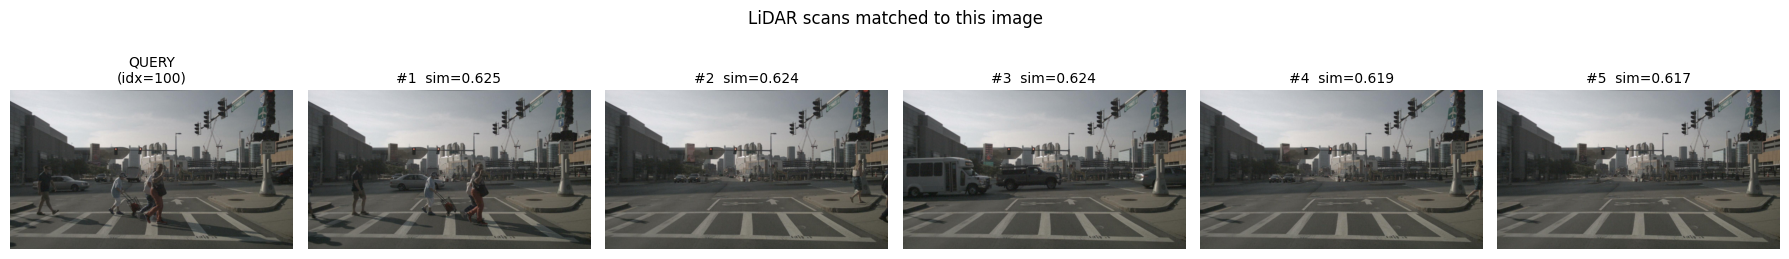

In [15]:
show_retrieval(query_idx=100, k=5, mode='image_to_lidar')

In [16]:
sample_317 = nusc.get('sample', index.sample_tokens[317])
scene_317 = nusc.get('scene', sample_317['scene_token'])
print(f"Scene 0 token: {nusc.get('sample', index.sample_tokens[0])['scene_token']}")
print(f"Scene 317 token: {sample_317['scene_token']}")
print(f"Scene 317 description: {scene_317['description']}")
print(f"Scene 317 location: {scene_317['log_token']}")

Scene 0 token: cc8c0bf57f984915a77078b10eb33198
Scene 317 token: d25718445d89453381c659b9c8734939
Scene 317 description: Night, big street, bus stop, high speed, construction vehicle
Scene 317 location: 8fefc430cbfa4c2191978c0df302eb98


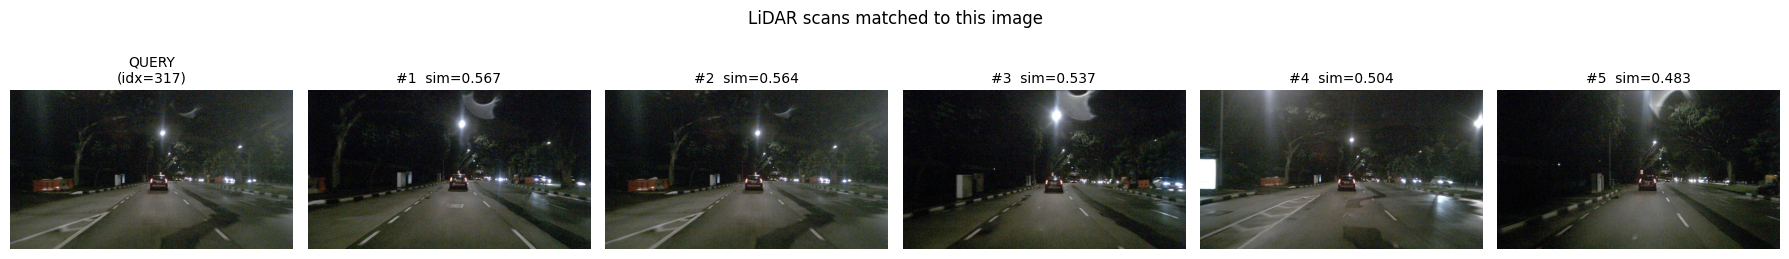

In [17]:
show_retrieval(query_idx=317, k=5, mode='image_to_lidar')